<a href="https://colab.research.google.com/github/muajnstu/Airlines_Review_Analysis_and_Topic_Modelling/blob/main/Sentiment_Classification_Module_on_Merged_Data_(D2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline Overview**
1. Install & Import
2. All Function Definitions
3. Data Loading & Preprocessing
4. TF-IDF Vectorisation + LSA  *(for KMeans clustering only)*
5. KMeans Clustering per Sentiment Class
6. Re-clustering (Synthetic-Minimising Strategy)
7. Cluster Filtering & Label Assignment
8. SMOTE — Classic ML only *(numeric LSA features)*
9. Original data split — DL & Transformer *(raw text, untouched)*
10. Classic ML — Train  *(on SMOTE-balanced LSA features)*
11. Deep Learning — Train *(on original text + class_weight)*
12. Transformer — Train *(on original text + class_weight)*
13. Results — Compare & Summarise

> **Design principle:**  
> SMOTE is applied **only to the numeric LSA features** consumed by Classic ML.  
> DL and Transformer models receive the **original unbalanced text** and handle  
> imbalance natively via class_weight in the loss function — because synthetic  
> interpolation in LSA space produces no meaningful text.


**Install Dependencies**

In [ ]:
!pip install -q imbalanced-learn xgboost lightgbm transformers torch

**Imports**

In [ ]:
import warnings, time, math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Perceptron, SGDClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.class_weight import compute_class_weight

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Conv1D, GlobalMaxPooling1D, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print('All imports successful.')

All imports successful.


**Global Constants**

In [ ]:
# ── Reproducibility
RANDOM_STATE   = 42

# ── TF-IDF / LSA  (used for clustering)
TFIDF_MAX_FEAT = 1000
LSA_COMPONENTS = 100

# ── KMeans / clustering
KMEANS_INIT       = 10
MIN_CLUSTER_RATIO = 0.40
ABS_MIN_CLUSTER   = 50

# ── Train / val / test split
TEST_SIZE = 0.20
VAL_SIZE  = 0.10

# ── Deep Learning
MAX_WORDS     = 20_000
MAX_LEN       = 100
EMBED_DIM     = 64
DL_EPOCHS     = 5
DL_BATCH_SIZE = 32

# ── Transformer
TRANSFORMER_MAX_LEN = 128
TRANSFORMER_EPOCHS  = 3
TRANSFORMER_BATCH   = 8
TRANSFORMER_LR      = 2e-5

# ── Label map
LABEL_MAP = {0: 'Positive', 1: 'Negative', 2: 'Mixed'}

# ── Classifiers that need scaled input
NEEDS_SCALE = {
    'LogisticRegression', 'RidgeClassifier', 'SGDClassifier', 'Perceptron',
    'GaussianNB', 'BernoulliNB', 'KNeighborsClassifier',
    'LinearDiscriminantAnalysis', 'QuadraticDiscriminantAnalysis',
    'LinearSVC', 'SVC_RBF', 'MLPClassifier',
}


**All Function Definitions**
> Run this cell once before any later section.


In [ ]:
# TEXT PREPROCESSING

_stop_words = set(stopwords.words('english'))
_lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Lowercase → strip non-alpha → remove stopwords → lemmatise."""
    text   = str(text).lower()
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [_lemmatizer.lemmatize(w) for w in tokens if w not in _stop_words]
    return ' '.join(tokens)

# CLUSTERING HELPERS

def synthetic_count(counts) -> int:
    m = max(counts)
    return sum(m - c for c in counts)


def plot_elbow_silhouette(X: np.ndarray, title: str) -> int:
    wcss, sil_scores, k_range = [], [], range(2, 11)
    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
        labels = km.fit_predict(X)
        wcss.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels, sample_size=min(2000, len(X))))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(k_range, wcss, marker='o')
    ax1.set_title(f'{title} — WCSS (Elbow)'); ax1.set_xlabel('k'); ax1.set_ylabel('WCSS')
    ax2.plot(k_range, sil_scores, marker='s', color='darkorange')
    ax2.set_title(f'{title} — Silhouette'); ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')
    plt.tight_layout(); plt.show()
    best_k = list(k_range)[sil_scores.index(max(sil_scores))]
    print(f'  Best k by silhouette: {best_k} (score={max(sil_scores):.3f})')
    return best_k


def split_large_clusters(X: np.ndarray, labels: np.ndarray,
                          min_cluster_size: int = ABS_MIN_CLUSTER) -> np.ndarray:
    new_labels = np.array(labels, dtype=object)
    for iteration in range(1, 50):
        unique, counts = np.unique(new_labels, return_counts=True)
        order          = np.argsort(-counts)
        unique, counts = unique[order], counts[order]
        if len(unique) < 2 or counts[0] <= counts[1]:
            break
        largest_name, largest_size, second_size = unique[0], counts[0], counts[1]
        k_min = math.ceil(largest_size / second_size)
        k_max = k_min + 2
        idx   = np.where(new_labels == largest_name)[0]
        X_sub = X[idx]
        print(f'Iter {iteration}: splitting "{largest_name}" '
              f'(n={largest_size}) into k={k_min}…{k_max} (second={second_size})')
        best_k, best_score, best_sublabels = None, -np.inf, None
        for k in range(k_min, k_max + 1):
            if k >= len(idx): break
            km         = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
            sub_lbl    = km.fit_predict(X_sub)
            sub_counts = np.bincount(sub_lbl)
            if sub_counts.min() < min_cluster_size:
                print(f'  k={k} rejected: smallest={sub_counts.min()} < {min_cluster_size}')
                continue
            sil = silhouette_score(X_sub, sub_lbl, sample_size=min(2000, len(X_sub)))
            print(f'  k={k}: sizes={sorted(sub_counts, reverse=True)}, sil={sil:.3f}')
            if sil > best_score:
                best_score, best_k, best_sublabels = sil, k, sub_lbl
        if best_k is None:
            print(f'  No valid split for "{largest_name}" — stopping.'); break
        for i, sub in zip(idx, best_sublabels):
            new_labels[i] = f'{largest_name}_{sub}'
        new_counts = np.bincount(best_sublabels)
        print(f'  => k={best_k} (sil={best_score:.3f}), sizes={sorted(new_counts, reverse=True)}')
        print(f'  => Synthetic count: {synthetic_count(np.unique(new_labels, return_counts=True)[1]):,}\n')
    return new_labels


# TRAIN / VAL / TEST SPLIT & SCALING

def split_and_scale(X: np.ndarray, y: np.ndarray,
                    test_size: float = TEST_SIZE, val_size: float = VAL_SIZE):
    """Stratified 80/10/10 split + StandardScaler. Returns raw + scaled splits."""
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y)
    val_frac = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_frac, random_state=RANDOM_STATE, stratify=y_tv)
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)
    print(f'Train : {X_train_sc.shape} | {Counter(y_train)}')
    print(f'Val   : {X_val_sc.shape}   | {Counter(y_val)}')
    print(f'Test  : {X_test_sc.shape}  | {Counter(y_test)}')
    return (X_train, X_val, X_test,
            X_train_sc, X_val_sc, X_test_sc,
            y_train, y_val, y_test, scaler)


# METRICS

def calculate_metrics(y_true, y_pred, y_proba, model_name: str) -> dict:
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except ValueError:
            auc = float('nan')
    else:
        auc = float('nan')
    return {'Model': model_name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'AUC': round(auc,4)}

# CLASSIC ML

def build_classifiers() -> dict:
    """Fresh dict of unfitted classifiers. No class_weight — SMOTE handles balance."""
    return {
        'LogisticRegression'           : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'RidgeClassifier'              : RidgeClassifier(),
        'SGDClassifier'                : SGDClassifier(max_iter=1000, random_state=RANDOM_STATE),
        'Perceptron'                   : Perceptron(max_iter=1000, random_state=RANDOM_STATE),
        'GaussianNB'                   : GaussianNB(),
        'BernoulliNB'                  : BernoulliNB(),
        'KNeighborsClassifier'         : KNeighborsClassifier(n_neighbors=5),
        'LinearDiscriminantAnalysis'   : LinearDiscriminantAnalysis(),
        'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(reg_param=0.1),
        'DecisionTreeClassifier'       : DecisionTreeClassifier(random_state=RANDOM_STATE),
        'RandomForestClassifier'       : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        'ExtraTreesClassifier'         : ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        'AdaBoostClassifier'           : AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'GradientBoostingClassifier'   : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
        'BaggingClassifier'            : BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        'LinearSVC'                    : LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
        'SVC_RBF'                      : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
        'XGBClassifier'                : XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0),
        'LGBMClassifier'               : LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbosity=-1),
        'MLPClassifier'                : MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300, random_state=RANDOM_STATE),
    }


def run_classic_ml(X_train, X_test, X_train_sc, X_test_sc, y_train, y_test) -> dict:
    classifiers = build_classifiers()
    results     = {}
    print(f'{"Model":<36}  {"Acc":>6}  {"F1":>6}  {"AUC":>6}  {"Time":>6}')
    print('-' * 65)
    for name, clf in classifiers.items():
        Xtr = X_train_sc if name in NEEDS_SCALE else X_train
        Xte = X_test_sc  if name in NEEDS_SCALE else X_test
        t0  = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            clf.fit(Xtr, y_train)
            y_pred = clf.predict(Xte)
        elapsed = time.time() - t0
        y_proba = None
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            if hasattr(clf, 'predict_proba'):
                y_proba = clf.predict_proba(Xte)
            elif hasattr(clf, 'decision_function'):
                df_scores = clf.decision_function(Xte)
                e = np.exp(df_scores - df_scores.max(axis=1, keepdims=True))
                y_proba = e / e.sum(axis=1, keepdims=True)
        m = calculate_metrics(y_test, y_pred, y_proba, name)
        m['Time(s)'] = round(elapsed, 2)
        results[name] = m
        print(f'{name:<36}  {m["Accuracy"]:>6.4f}  {m["F1"]:>6.4f}  {m["AUC"]:>6.4f}  {elapsed:>5.1f}s')
    return results

# DEEP LEARNING  (Keras)

def prepare_dl_data(X_train_raw, X_val_raw, X_test_raw,
                    y_train, y_val, y_test):
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train_raw)
    def _seq(X): return pad_sequences(tokenizer.texts_to_sequences(X), maxlen=MAX_LEN)
    X_train_seq = _seq(X_train_raw)
    X_val_seq   = _seq(X_val_raw)
    X_test_seq  = _seq(X_test_raw)
    if hasattr(y_train, 'values'): y_train = y_train.values
    if hasattr(y_val,   'values'): y_val   = y_val.values
    if hasattr(y_test,  'values'): y_test  = y_test.values
    print(f'DL sequences — train:{X_train_seq.shape}  val:{X_val_seq.shape}  test:{X_test_seq.shape}')
    return X_train_seq, X_val_seq, X_test_seq, y_train, y_val, y_test, tokenizer


def create_lstm():   return Sequential([Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN), LSTM(128), Dense(3, activation='softmax')])
def create_gru():    return Sequential([Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN), GRU(128), Dense(3, activation='softmax')])
def create_cnn():    return Sequential([Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN), Conv1D(128,5,activation='relu'), GlobalMaxPooling1D(), Dense(3, activation='softmax')])
def create_bilstm(): return Sequential([Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN), Bidirectional(LSTM(128)), Dense(3, activation='softmax')])


def train_dl_model(name, model_fn,
                   X_train_seq, y_train, X_val_seq, y_val,
                   X_test_seq, y_test, class_weight_dict) -> dict:
    """Train one Keras model with class_weight to handle original imbalance."""
    print(f'\nTraining {name}...')
    model = model_fn()
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.fit(X_train_seq, y_train,
              epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
              validation_data=(X_val_seq, y_val),
              class_weight=class_weight_dict,   # ← handles imbalance natively
              verbose=1)
    y_proba = model.predict(X_test_seq, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)
    return calculate_metrics(y_test, y_pred, y_proba, name)


def run_dl_models(X_train_seq, y_train_dl, X_val_seq, y_val_dl,
                  X_test_seq, y_test_dl, class_weight_dict) -> dict:
    dl_results = {}
    for name, fn in [('LSTM', create_lstm), ('GRU', create_gru),
                     ('CNN', create_cnn), ('BiLSTM', create_bilstm)]:
        dl_results[name] = train_dl_model(name, fn,
                                          X_train_seq, y_train_dl,
                                          X_val_seq,   y_val_dl,
                                          X_test_seq,  y_test_dl,
                                          class_weight_dict)
    return dl_results


# TRANSFORMER  (PyTorch / HuggingFace)

class WeightedLossTrainer(Trainer):
    """Trainer subclass that applies class weights to the cross-entropy loss."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights   # torch.Tensor on correct device

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        device  = logits.device
        weights = self.class_weights.to(device) if self.class_weights is not None else None
        loss    = torch.nn.functional.cross_entropy(logits, labels, weight=weights)
        return (loss, outputs) if return_outputs else loss


class TorchTextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        if hasattr(labels, 'values'): labels = labels.values
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.encodings = encodings
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item
    def __len__(self): return len(self.labels)


def _tokenize_for_transformer(tokenizer, X, max_length=TRANSFORMER_MAX_LEN):
    return tokenizer(list(X), add_special_tokens=True, max_length=max_length,
                     padding='max_length', truncation=True,
                     return_attention_mask=True, return_tensors='pt')


def train_pytorch_transformer(model_name, checkpoint, num_labels,
                               X_train, y_train, X_val, y_val, X_test, y_test,
                               class_weight_tensor,
                               max_length=TRANSFORMER_MAX_LEN) -> dict:
    print(f'\n{"="*70}\nTRAINING {model_name}\n{"="*70}')
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model     = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels)
    model.config.problem_type = 'single_label_classification'

    train_ds = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_train, max_length), y_train)
    val_ds   = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_val,   max_length), y_val)
    test_ds  = TorchTextDataset(_tokenize_for_transformer(tokenizer, X_test,  max_length), y_test)

    training_args = TrainingArguments(
        output_dir=f'./results_{model_name.lower()}',
        num_train_epochs=TRANSFORMER_EPOCHS,
        per_device_train_batch_size=TRANSFORMER_BATCH,
        per_device_eval_batch_size=TRANSFORMER_BATCH,
        learning_rate=TRANSFORMER_LR, warmup_ratio=0.1,
        eval_strategy='epoch', save_strategy='no',
        logging_strategy='epoch', max_grad_norm=1.0, report_to='none'
    )
    trainer = WeightedLossTrainer(          # ← weighted loss handles imbalance
        model=model, args=training_args,
        train_dataset=train_ds, eval_dataset=val_ds,
        class_weights=class_weight_tensor
    )
    trainer.train()

    test_outputs = trainer.predict(test_ds)
    logits  = test_outputs.predictions
    y_pred  = np.argmax(logits, axis=1)
    probs   = torch.nn.functional.softmax(torch.tensor(logits), dim=1)
    y_proba = torch.nan_to_num(probs).cpu().numpy()
    y_true  = y_test.values if hasattr(y_test, 'values') else y_test
    return calculate_metrics(y_true, y_pred, y_proba, model_name)


def run_transformer_models(X_train, y_train, X_val, y_val, X_test, y_test,
                            num_labels, class_weight_tensor) -> dict:
    checkpoints = {
        'BERT'      : 'bert-base-uncased',
        'RoBERTa'   : 'roberta-base',
        'DistilBERT': 'distilbert-base-uncased',
        'ALBERT'    : 'albert-base-v2',
    }
    results = {}
    for name, ckpt in checkpoints.items():
        results[name] = train_pytorch_transformer(
            name, ckpt, num_labels,
            X_train, y_train, X_val, y_val, X_test, y_test,
            class_weight_tensor)
    return results

# REPORTING

def build_results_df(all_results: dict) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(all_results, orient='index')
    df.index.name = 'Model'
    return df.drop(columns=['Model'], errors='ignore').sort_values('Accuracy', ascending=False)


def plot_model_comparison(results_df, metric='F1', top_n=15):
    top = results_df.sort_values(metric, ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top.index[::-1], top[metric][::-1], color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'Top-{top_n} Models — {metric}')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, top[metric][::-1]):
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(y_true, y_pred, model_name,
                           class_names=('Positive','Negative','Mixed')):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout(); plt.show()


print('All functions defined.')


All functions defined.


**Data Loading & Preprocessing**

In [ ]:
url = 'https://raw.githubusercontent.com/muajnstu/Airlines_Review_Analysis_and_Topic_Modelling/refs/heads/main/Dataset_2.csv'
df  = pd.read_csv(url)
print(df.head())
print('\nSentiment distribution:')
print(df['sentiment'].value_counts())

                                              review sentiment
0  Hong Kong to Brisbane via Taipei. Hong Kong to...  Negative
1  Jakarta to Vancouver via Taipei. First time fl...  Positive
2  Myself my mother and my husband flew Gatwick t...  Negative
3  They have no regard for consumer rights and wi...  Negative
4  The check-in in this case was a bit more compl...     Mixed

Sentiment distribution:
sentiment
Negative    3494
Positive    2037
Mixed       1547
Name: count, dtype: int64


In [ ]:
df_cleaned = df.copy()

# Drop duplicates
before = df_cleaned.shape
df_cleaned = df_cleaned.drop_duplicates()
print(f'Duplicates removed: {before[0] - df_cleaned.shape[0]} rows')
print(f'Shape: {before} → {df_cleaned.shape}')

# Clean text
df_cleaned['review'] = df_cleaned['review'].apply(clean_text)
print('\nSample cleaned reviews:')
print(df_cleaned['review'].head())

Duplicates removed: 1 rows
Shape: (7078, 2) → (7077, 2)

Sample cleaned reviews:
0    hong kong brisbane via taipei hong kong taipei...
1    jakarta vancouver via taipei first time flying...
2    mother husband flew gatwick sydney via taipei ...
3    regard consumer right destroy itinerary dont e...
4    checkin case bit complex flight ability taipei...
Name: review, dtype: object


**TF-IDF Vectorisation + LSA**

> LSA reduces dimensionality for KMeans clustering. Classic ML will also train on these LSA features.

In [ ]:
tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEAT, stop_words=list(_stop_words))
X_vectorized = tfidf.fit_transform(df_cleaned['review'])
print('TF-IDF shape:', X_vectorized.shape)

svd = TruncatedSVD(n_components=LSA_COMPONENTS, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X_vectorized)
explained = svd.explained_variance_ratio_.sum()
print(f'LSA: {LSA_COMPONENTS} components explain {explained:.1%} of variance')
print('Reduced shape:', X_reduced.shape)

TF-IDF shape: (7077, 1000)
LSA: 100 components explain 33.5% of variance
Reduced shape: (7077, 100)


**Clustering per Sentiment Class**

In [ ]:
y_labels = df_cleaned['sentiment'].values

X_pos = X_reduced[y_labels == 'Positive']
X_neg = X_reduced[y_labels == 'Negative']
X_neu = X_reduced[y_labels == 'Mixed']

print('Positive:', X_pos.shape)
print('Negative:', X_neg.shape)
print('Mixed   :', X_neu.shape)

Positive: (2037, 100)
Negative: (3494, 100)
Mixed   : (1546, 100)


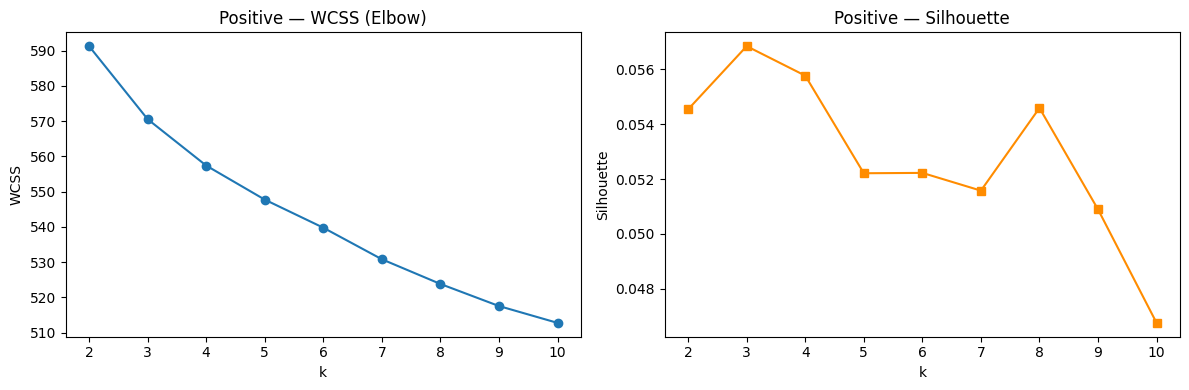

  Best k by silhouette: 3 (score=0.057)


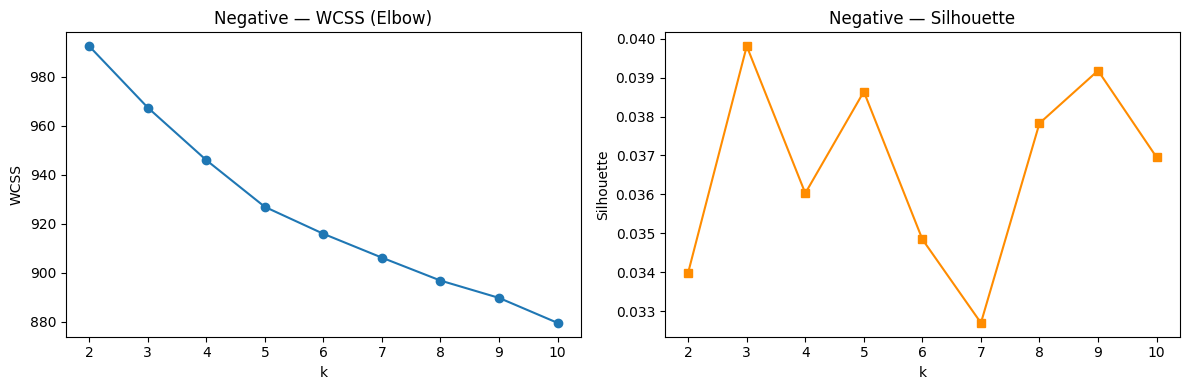

  Best k by silhouette: 3 (score=0.040)


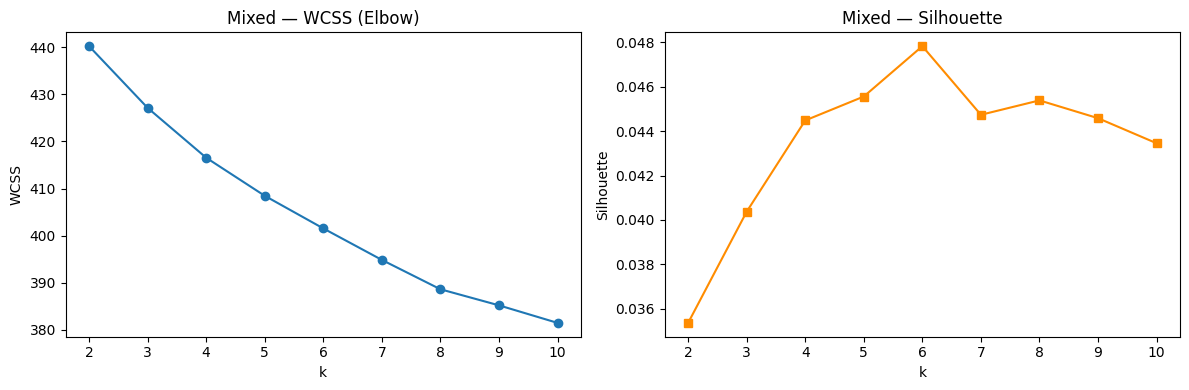

  Best k by silhouette: 6 (score=0.048)


In [ ]:
# Elbow + silhouette — inspect plots before proceeding
best_k_pos = plot_elbow_silhouette(X_pos, 'Positive')
best_k_neg = plot_elbow_silhouette(X_neg, 'Negative')
best_k_neu = plot_elbow_silhouette(X_neu, 'Mixed')

In [ ]:
# Override any k here if the plots suggest a different choice
n_clusters_positive = best_k_pos
n_clusters_negative = best_k_neg
n_clusters_neutral  = best_k_neu

km_pos = KMeans(n_clusters=n_clusters_positive, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
km_neg = KMeans(n_clusters=n_clusters_negative, random_state=RANDOM_STATE, n_init=KMEANS_INIT)
km_neu = KMeans(n_clusters=n_clusters_neutral,  random_state=RANDOM_STATE, n_init=KMEANS_INIT)

labels_pos = km_pos.fit_predict(X_pos)
labels_neg = km_neg.fit_predict(X_neg)
labels_neu = km_neu.fit_predict(X_neu)

print('Cluster distribution:')
print('  Positive:', np.bincount(labels_pos))
print('  Negative:', np.bincount(labels_neg))
print('  Mixed   :', np.bincount(labels_neu))

Cluster distribution:
  Positive: [ 574  360 1103]
  Negative: [ 402 1318 1774]
  Mixed   : [204  67 556 219 206 294]


**Cluster + Re-clustering**

In [ ]:
df_pos = pd.DataFrame(X_pos); df_pos['target'] = 'Positive'; df_pos['Cluster_Label'] = ['Positive_' + str(i+1) for i in labels_pos]
df_neg = pd.DataFrame(X_neg); df_neg['target'] = 'Negative'; df_neg['Cluster_Label'] = ['Negative_' + str(i+1) for i in labels_neg]
df_neu = pd.DataFrame(X_neu); df_neu['target'] = 'Mixed';    df_neu['Cluster_Label'] = ['Mixed_'    + str(i+1) for i in labels_neu]

final_df = pd.concat([df_pos, df_neg, df_neu], ignore_index=True)
print('Cluster distribution (initial):')
print(final_df['Cluster_Label'].value_counts())
print(f'\nInitial synthetic count estimate: {synthetic_count(final_df["Cluster_Label"].value_counts().values):,}')

Cluster distribution (initial):
Cluster_Label
Negative_3    1774
Negative_2    1318
Positive_3    1103
Positive_1     574
Mixed_3        556
Negative_1     402
Positive_2     360
Mixed_6        294
Mixed_4        219
Mixed_5        206
Mixed_1        204
Mixed_2         67
Name: count, dtype: int64

Initial synthetic count estimate: 14,211


In [ ]:
X_features   = final_df.drop(columns=['target', 'Cluster_Label']).values
labels_array = final_df['Cluster_Label'].to_numpy()

new_labels = split_large_clusters(X_features, labels_array, min_cluster_size=ABS_MIN_CLUSTER)

counts_after = pd.Series(new_labels).value_counts()
print('\nAfter re-clustering:')
print(counts_after)
print(f'\nFinal synthetic count estimate: {synthetic_count(counts_after.values):,}')
print(f'Max cluster: {counts_after.max()}, Min cluster: {counts_after.min()}')

Iter 1: splitting "Negative_3" (n=1774) into k=2…4 (second=1318)
  k=2: sizes=[np.int64(1337), np.int64(437)], sil=0.039
  k=3: sizes=[np.int64(863), np.int64(521), np.int64(390)], sil=0.033
  k=4: sizes=[np.int64(650), np.int64(515), np.int64(446), np.int64(163)], sil=0.034
  => k=2 (sil=0.039), sizes=[np.int64(1337), np.int64(437)]
  => Synthetic count: 10,304

Iter 2: splitting "Negative_3_0" (n=1337) into k=2…4 (second=1318)
  k=2: sizes=[np.int64(755), np.int64(582)], sil=0.031
  k=3: sizes=[np.int64(621), np.int64(362), np.int64(354)], sil=0.030
  k=4: sizes=[np.int64(591), np.int64(368), np.int64(238), np.int64(140)], sil=0.032
  => k=4 (sil=0.032), sizes=[np.int64(591), np.int64(368), np.int64(238), np.int64(140)]
  => Synthetic count: 14,011

Iter 3: splitting "Negative_2" (n=1318) into k=2…4 (second=1103)
  k=2: sizes=[np.int64(681), np.int64(637)], sil=0.033
  k=3: sizes=[np.int64(500), np.int64(415), np.int64(403)], sil=0.030
  k=4: sizes=[np.int64(458), np.int64(376), np.i

**Filtering & Label Assignment**

In [ ]:
cluster_counts  = pd.Series(new_labels).value_counts()
median_size     = cluster_counts.median()
MIN_CLUSTER_SIZE = max(ABS_MIN_CLUSTER, int(MIN_CLUSTER_RATIO * median_size))

print(f'Median cluster size : {median_size:.0f}')
print(f'Filter threshold    : {MIN_CLUSTER_SIZE}')

small_clusters = cluster_counts[cluster_counts < MIN_CLUSTER_SIZE].index.tolist()
print(f'Clusters to drop ({len(small_clusters)}):', small_clusters)

df_recluster = final_df.copy()
df_recluster['Cluster_Label'] = new_labels
filtered_df  = df_recluster[~df_recluster['Cluster_Label'].isin(small_clusters)].copy()

print('\nShape after filtering:', filtered_df.shape)
print('\nRemaining cluster sizes:')
print(filtered_df['Cluster_Label'].value_counts())

Median cluster size : 273
Filter threshold    : 109
Clusters to drop (4): ['Mixed_2', 'Mixed_3_1', 'Positive_3_2_0', 'Positive_3_1']

Shape after filtering: (6821, 102)

Remaining cluster sizes:
Cluster_Label
Negative_3_0_3_1    466
Negative_2_2        458
Negative_3_1        437
Negative_1          402
Positive_3_2_1      396
Negative_2_3        376
Negative_3_0_1      368
Positive_2          360
Negative_2_0        351
Positive_3_0        344
Positive_1_1        301
Mixed_6             294
Mixed_3_0_1         290
Positive_1_0        273
Positive_3_2_2      241
Negative_3_0_2      238
Mixed_4             219
Mixed_5             206
Mixed_1             204
Mixed_3_0_0         199
Negative_3_0_0      140
Negative_2_1        133
Negative_3_0_3_0    125
Name: count, dtype: int64


In [ ]:
def _sentiment_sort_key(label):
    order = {'Positive': 0, 'Negative': 1, 'Mixed': 2}
    prefix = label.split('_')[0]
    return (order.get(prefix, 99), label)

sorted_labels = sorted(filtered_df['Cluster_Label'].unique(), key=_sentiment_sort_key)
cluster_label_to_serial = {lbl: f'label_{i}' for i, lbl in enumerate(sorted_labels)}

filtered_df['Serial_Cluster_Label'] = (
    filtered_df['Cluster_Label']
    .map(cluster_label_to_serial)
    .apply(lambda x: int(x.split('_')[1]))
)
filtered_df = filtered_df.drop(columns=['Cluster_Label'])

print('Serial cluster distribution:')
print(filtered_df['Serial_Cluster_Label'].value_counts().sort_index())

Serial cluster distribution:
Serial_Cluster_Label
0     273
1     301
2     360
3     344
4     396
5     241
6     402
7     351
8     133
9     458
10    376
11    140
12    368
13    238
14    125
15    466
16    437
17    204
18    199
19    290
20    219
21    206
22    294
Name: count, dtype: int64


**Balancing**

> SMOTE is applied exclusively to the **numeric LSA features** that Classic ML classifiers consume.  
> DL and Transformer models are **not** involved here — they will use the original text data directly.


In [ ]:
original_indices = filtered_df.index.values
filtered_df      = filtered_df.reset_index(drop=True)

X_smote_input = filtered_df.drop(columns=['target', 'Serial_Cluster_Label']).values
y_smote_input = filtered_df['Serial_Cluster_Label'].values

print('Class distribution BEFORE SMOTE:')
for k, v in sorted(Counter(y_smote_input).items()):
    print(f'  label_{k}: {v}')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_balanced, y_balanced_clusters = smote.fit_resample(X_smote_input, y_smote_input)

print(f'\nAfter SMOTE: {X_balanced.shape[0]:,} total samples '
      f'({X_balanced.shape[0] - len(X_smote_input):,} synthetic added)')
print('Class distribution AFTER SMOTE:')
for k, v in sorted(Counter(y_balanced_clusters).items()):
    print(f'  label_{k}: {v}')

Class distribution BEFORE SMOTE:
  label_0: 273
  label_1: 301
  label_2: 360
  label_3: 344
  label_4: 396
  label_5: 241
  label_6: 402
  label_7: 351
  label_8: 133
  label_9: 458
  label_10: 376
  label_11: 140
  label_12: 368
  label_13: 238
  label_14: 125
  label_15: 466
  label_16: 437
  label_17: 204
  label_18: 199
  label_19: 290
  label_20: 219
  label_21: 206
  label_22: 294

After SMOTE: 10,718 total samples (3,897 synthetic added)
Class distribution AFTER SMOTE:
  label_0: 466
  label_1: 466
  label_2: 466
  label_3: 466
  label_4: 466
  label_5: 466
  label_6: 466
  label_7: 466
  label_8: 466
  label_9: 466
  label_10: 466
  label_11: 466
  label_12: 466
  label_13: 466
  label_14: 466
  label_15: 466
  label_16: 466
  label_17: 466
  label_18: 466
  label_19: 466
  label_20: 466
  label_21: 466
  label_22: 466


In [ ]:
# Map fine-grained cluster labels back to 3-class sentiment
serial_to_cluster = {int(v.split('_')[1]): k for k, v in cluster_label_to_serial.items()}

def _cluster_to_sentiment(serial_int: int) -> int:
    cluster_str = serial_to_cluster[serial_int]
    if cluster_str.startswith('Positive'): return 0
    if cluster_str.startswith('Negative'): return 1
    return 2

y_balanced = np.array([_cluster_to_sentiment(c) for c in y_balanced_clusters])

print('Final 3-class distribution after SMOTE:')
for k, v in sorted(Counter(y_balanced).items()):
    print(f'  {LABEL_MAP[k]}: {v:,}')

Final 3-class distribution after SMOTE:
  Positive: 2,796
  Negative: 5,126
  Mixed: 2,796


**Train / Val / Test Split — Classic ML (SMOTE-balanced LSA features)**

In [ ]:
(
    X_train, X_val, X_test,
    X_train_sc, X_val_sc, X_test_sc,
    y_train, y_val, y_test,
    scaler
) = split_and_scale(X_balanced, y_balanced)

print(f'\nClassic ML is training on {X_train.shape[0]:,} SMOTE-balanced samples.')


Train : (7502, 100) | Counter({np.int64(1): 3588, np.int64(0): 1957, np.int64(2): 1957})
Val   : (1072, 100)   | Counter({np.int64(1): 512, np.int64(2): 280, np.int64(0): 280})
Test  : (2144, 100)  | Counter({np.int64(1): 1026, np.int64(0): 559, np.int64(2): 559})

Classic ML is training on 7,502 SMOTE-balanced samples.


**Data Split for DL & Transformer (without SMOTE instances)**

In [ ]:
le_orig = LabelEncoder()
y_orig  = le_orig.fit_transform(df_cleaned['sentiment'].values)
# Ensure order matches LABEL_MAP
label_order = ['Positive', 'Negative', 'Mixed']
y_orig = np.array([label_order.index(s) for s in df_cleaned['sentiment'].values])

text_orig = df_cleaned['review'].values

print('Original class distribution:')
for k, v in sorted(Counter(y_orig).items()):
    print(f'  {LABEL_MAP[k]}: {v}')

# split on original data
text_tv, text_test_orig, y_tv_orig, y_test_orig = train_test_split(
    text_orig, y_orig,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_orig
)
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
text_train_orig, text_val_orig, y_train_orig, y_val_orig = train_test_split(
    text_tv, y_tv_orig,
    test_size=val_frac, random_state=RANDOM_STATE, stratify=y_tv_orig
)

print(f'\nOriginal data splits:')
print(f'  Train : {len(text_train_orig):,} | {Counter(y_train_orig)}')
print(f'  Val   : {len(text_val_orig):,}   | {Counter(y_val_orig)}')
print(f'  Test  : {len(text_test_orig):,}  | {Counter(y_test_orig)}')

# Compute class weights from training labels
cw_values = compute_class_weight('balanced', classes=np.unique(y_train_orig), y=y_train_orig)
class_weight_dict   = dict(enumerate(cw_values))
class_weight_tensor = torch.tensor(cw_values, dtype=torch.float32)

print(f'\nClass weights: {class_weight_dict}')


Original class distribution:
  Positive: 2037
  Negative: 3494
  Mixed: 1546

Original data splits:
  Train : 4,953 | Counter({np.int64(1): 2446, np.int64(0): 1425, np.int64(2): 1082})
  Val   : 708   | Counter({np.int64(1): 349, np.int64(0): 204, np.int64(2): 155})
  Test  : 1,416  | Counter({np.int64(1): 699, np.int64(0): 408, np.int64(2): 309})

Class weights: {0: np.float64(1.1585964912280702), 1: np.float64(0.6749795584627964), 2: np.float64(1.5258780036968578)}


**Classic ML — Train All Classifiers**

> Trained on SMOTE-balanced instances

In [ ]:
classic_ml_results = run_classic_ml(
    X_train, X_test,
    X_train_sc, X_test_sc,
    y_train, y_test
)


Model                                    Acc      F1     AUC    Time
-----------------------------------------------------------------
LogisticRegression                    0.7901  0.7858  0.9188    0.4s
RidgeClassifier                       0.7645  0.7487  0.9026    0.1s
SGDClassifier                         0.7663  0.7532  0.8988    0.9s
Perceptron                            0.7318  0.7279  0.8642    0.1s
GaussianNB                            0.6926  0.6977  0.8482    0.0s
BernoulliNB                           0.6819  0.6784  0.8388    0.0s
KNeighborsClassifier                  0.7332  0.7363  0.8833    0.5s
LinearDiscriminantAnalysis            0.7859  0.7838  0.9133    0.5s
QuadraticDiscriminantAnalysis         0.7500  0.7512  0.8932    1.2s
DecisionTreeClassifier                0.7444  0.7442  0.7921    3.2s
RandomForestClassifier                0.8619  0.8575  0.9651   32.0s
ExtraTreesClassifier                  0.8815  0.8776  0.9741    6.0s
AdaBoostClassifier                   

**Deep Learning — LSTM / GRU / CNN / BiLSTM**

> Trained on original text

In [ ]:
print('Preparing Deep Learning sequences (original text)...')

X_train_dl, X_val_dl, X_test_dl, \
y_train_dl, y_val_dl, y_test_dl, \
dl_tokenizer = prepare_dl_data(
    text_train_orig, text_val_orig, text_test_orig,
    y_train_orig,    y_val_orig,    y_test_orig
)

print('\n DL data ready!')
print(f'   Train : {X_train_dl.shape}')
print(f'   Val   : {X_val_dl.shape}')
print(f'   Test  : {X_test_dl.shape}')


Preparing Deep Learning sequences (original text)...
DL sequences — train:(4953, 100)  val:(708, 100)  test:(1416, 100)

 DL data ready!
   Train : (4953, 100)
   Val   : (708, 100)
   Test  : (1416, 100)


In [ ]:
dl_results = run_dl_models(
    X_train_dl, y_train_dl,
    X_val_dl,   y_val_dl,
    X_test_dl,  y_test_dl,
    class_weight_dict
)



Training LSTM...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


155/155 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6493 - loss: 0.8380 - val_accuracy: 0.7528 - val_loss: 0.6349
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7789 - loss: 0.6046 - val_accuracy: 0.7768 - val_loss: 0.5875
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8639 - loss: 0.4285 - val_accuracy: 0.7684 - val_loss: 0.5901
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9170 - loss: 0.2774 - val_accuracy: 0.7585 - val_loss: 0.6969
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9568 - loss: 0.1507 - val_accuracy: 0.7345 - val_loss: 0.8693

Training GRU...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6237 - loss: 0.8739 - val_accuracy: 0.7260 - val_loss: 0.6497
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7927 - loss: 0.5779 - val_accuracy: 0.7373 - val_loss: 0.6399
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8754 - loss: 0.3690 - val_accuracy: 0.7020 - val_loss: 0.7680
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9245 - loss: 0.2261 - val_accuracy: 0.6271 - val_loss: 0.9811
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9548 - loss: 0.1334 - val_accuracy: 0.6850 - val_loss: 1.0502

Training CNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6402 - loss: 0.9030 - val_accuracy: 0.7556 - val_loss: 0.6147
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7947 - loss: 0.5675 - val_accuracy: 0.8051 - val_loss: 0.5021
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8827 - loss: 0.3737 - val_accuracy: 0.7938 - val_loss: 0.5199
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9477 - loss: 0.2044 - val_accuracy: 0.7754 - val_loss: 0.5336
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9838 - loss: 0.0880 - val_accuracy: 0.7712 - val_loss: 0.6158

Training BiLSTM...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6372 - loss: 0.8516 - val_accuracy: 0.6653 - val_loss: 0.7260
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7801 - loss: 0.5950 - val_accuracy: 0.7331 - val_loss: 0.6385
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8546 - loss: 0.4296 - val_accuracy: 0.6992 - val_loss: 0.7277
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9095 - loss: 0.2777 - val_accuracy: 0.7387 - val_loss: 0.7262
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9524 - loss: 0.1608 - val_accuracy: 0.7429 - val_loss: 0.8075


**Transformer Fine-tuning — BERT / RoBERTa / DistilBERT / ALBERT**

> ⚠️ Requires GPU. Enable in Colab: *Runtime → Change runtime type → T4 GPU*  
> Trained on original text.

In [ ]:
num_classes = len(np.unique(y_orig))
print(f'Number of classes : {num_classes}')
print(f'Class weight tensor: {class_weight_tensor}')

transformer_results = run_transformer_models(
    text_train_orig, y_train_orig,
    text_val_orig,   y_val_orig,
    text_test_orig,  y_test_orig,
    num_labels=num_classes,
    class_weight_tensor=class_weight_tensor
)


Number of classes : 3
Class weight tensor: tensor([1.1586, 0.6750, 1.5259])

TRAINING BERT


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,0.670025,0.647420
2,0.474561,0.442007
3,0.361932,0.565251


**Results — Compare All Models**

In [ ]:
all_results = {
    **classic_ml_results,
    **dl_results,
    **transformer_results
}

results_df = build_results_df(all_results)
print('\n--- Full Model Performance Summary ---\n')
print(results_df.round(4).to_string())



--- Full Model Performance Summary ---

                               Accuracy  Precision  Recall      F1     AUC  Time(s)
Model                                                                              
MLPClassifier                    0.8923     0.8913  0.8923  0.8917  0.9612     9.02
XGBClassifier                    0.8839     0.8814  0.8839  0.8820  0.9665    13.97
ExtraTreesClassifier             0.8815     0.8839  0.8815  0.8776  0.9741     6.02
LGBMClassifier                   0.8787     0.8762  0.8787  0.8768  0.9641     9.79
SVC_RBF                          0.8750     0.8722  0.8750  0.8721  0.9657    22.15
BERT                             0.8630     0.8622  0.8630  0.8624  0.9548      NaN
RandomForestClassifier           0.8619     0.8611  0.8619  0.8575  0.9651    31.97
DistilBERT                       0.8475     0.8435  0.8475  0.8451  0.9541      NaN
BaggingClassifier                0.8470     0.8431  0.8470  0.8433  0.9562    83.75
RoBERTa                          0.

In [ ]:
top3_df = results_df.head(3)
print('\n--- Top 3 Models (by AUC) ---\n')
print(top3_df.round(4))
print('\nTop 3:', top3_df.index.tolist())



--- Top 3 Models (by AUC) ---

                      Accuracy  Precision  Recall      F1     AUC  Time(s)
Model                                                                     
MLPClassifier           0.8923     0.8913  0.8923  0.8917  0.9612     9.02
XGBClassifier           0.8839     0.8814  0.8839  0.8820  0.9665    13.97
ExtraTreesClassifier    0.8815     0.8839  0.8815  0.8776  0.9741     6.02

Top 3: ['MLPClassifier', 'XGBClassifier', 'ExtraTreesClassifier']


Best model: MLPClassifier

              precision    recall  f1-score   support

    Positive       0.87      0.86      0.87       559
    Negative       0.94      0.96      0.95      1026
       Mixed       0.82      0.80      0.81       559

    accuracy                           0.89      2144
   macro avg       0.88      0.87      0.88      2144
weighted avg       0.89      0.89      0.89      2144



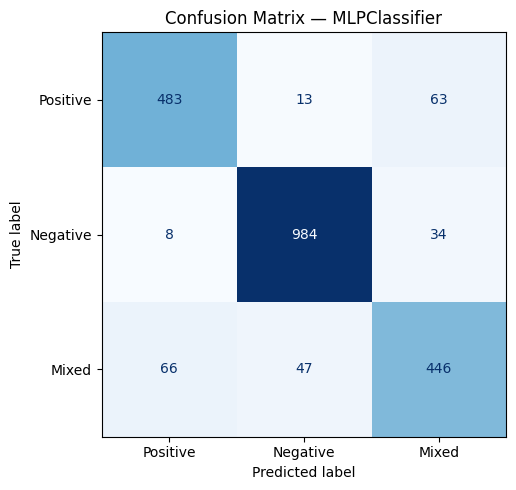

In [ ]:
# ── Best model evaluation ──────────────────────────────────────────────────────
best_name = results_df.index[0]
print(f'Best model: {best_name}\n')

if best_name in build_classifiers():
    clf = build_classifiers()[best_name]
    Xtr = X_train_sc if best_name in NEEDS_SCALE else X_train
    Xte = X_test_sc  if best_name in NEEDS_SCALE else X_test
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        clf.fit(Xtr, y_train)
        y_pred_best = clf.predict(Xte)
    print(classification_report(y_test, y_pred_best, target_names=list(LABEL_MAP.values())))
    plot_confusion_matrix(y_test, y_pred_best, best_name)
else:
    print('Best model is DL/Transformer — re-run its training cell for predictions.')


**Save Artifacts**

Run this cell after the best model is confirmed.  
It saves all fitted preprocessors and the best classifier to disk so that the  
Topic Modelling notebook can load them directly — **no retraining needed**.

| File | Contains |
|---|---|
| `tfidf_vectorizer.pkl` | Fitted `TfidfVectorizer` (vocabulary frozen) |
| `svd_lsa.pkl` | Fitted `TruncatedSVD` — LSA components frozen |
| `scaler.pkl` | Fitted `StandardScaler` — mean/std frozen |
| `label_encoder.pkl` | Fitted `LabelEncoder` — class order frozen |
| `best_model.pkl` | Trained best classifier (`ExtraTreesClassifier`) |


In [ ]:
if best_name in build_classifiers():
    best_clf_to_save = build_classifiers()[best_name]
    Xtr_full = X_train_sc if best_name in NEEDS_SCALE else X_train
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        best_clf_to_save.fit(Xtr_full, y_train)
    print(f'Best classifier re-fitted on full training set: {best_name}')
else:
    best_clf_to_save = None
    print(f'NOTE: {best_name} is a DL/Transformer model.')
    print('Save it using model.save() or trainer.save_model() and adapt Steps 4-8 loader.')

# Save all fitted preprocessors and the best model
artifacts = {
    'tfidf_vectorizer.pkl': tfidf,
    'svd_lsa.pkl':          svd,
    'scaler.pkl':           scaler,
    'label_encoder.pkl':    le_orig,
    'best_model.pkl':       best_clf_to_save,
}

for filename, obj in artifacts.items():
    if obj is not None:
        with open(filename, 'wb') as f:
            pickle.dump(obj, f)
        print(f'  Saved: {filename}')

print()
print('All artifacts saved. Download them from the Colab Files panel')
